#**Instalación de Librerías**

In [2]:
!pip install wandb
!pip install tensorflow

#**Importar Librerías**

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import wandb
from wandb.integration.keras import WandbMetricsLogger

epocas=10

#**Data Journey**

#**Carga del Dataset**

In [4]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#**Exploración de Datos**

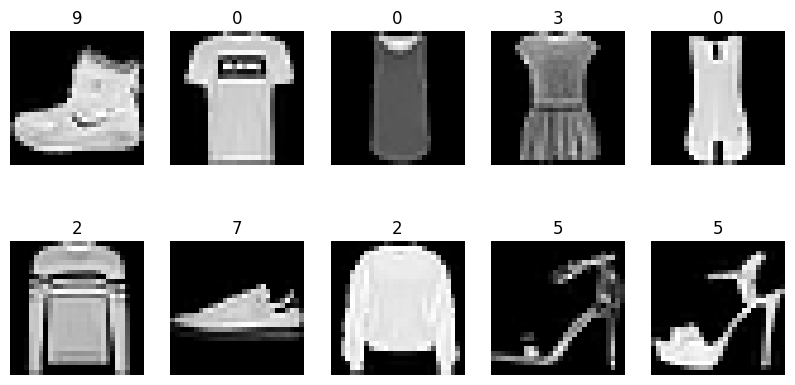

In [5]:
plt.figure(figsize=(10,5))

for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(X_train[i], cmap='gray')
  plt.title(y_train[i])
  plt.axis('off')
plt.show()

#**Manipulación y Preparación de Datos**

In [6]:
X_train=X_train /255.0
X_test=X_test /255.0

REdimensionando

In [7]:
X_train=X_train.reshape(-1,28,28,1)
X_test=X_test.reshape(-1,28,28,1)

#**Inicialización de Weights & Biases**

In [ ]:
wandb.login()

wandb.init(
    project="fashion-mnist-monitoring",
    name="cnn-basica"

)

#**Construcción del modelo**

In [ ]:
model=keras.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

#**Compilación**

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#**Entrenamiento con Logging**

In [ ]:
history=model.fit(
    X_train,
    y_train,
    epochs=epocas,
    validation_data=(X_test, y_test),

    callbacks=[
        WandbMetricsLogger()
    ]
)

#**Evaluación**

In [ ]:
loss, accuracy=model.evaluate(X_test, y_test)

print("loss: ", loss)
print("Accuracy: ", accuracy)

#**Predicciones**

In [ ]:
Predicciones=model.predict(X_test)

Mostrar Imágenes

In [ ]:
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicción: {np.argmax(Predicciones[0])}")
plt.axis("off")
plt.show()